# 09 · Selección de pizarra — de un video de 6 minutos a una sola imagen

Antes de que Stage 1 vea nada, hay que decidir **qué frame** del video se le manda. Un
episodio de *This is My Architecture* dura ~6 minutos; a un frame cada 10 segundos son
entre 50 y 200 candidatos, de los cuales sirve **uno**: aquel donde el diagrama está
completo y el presentador no lo tapa.

Este notebook documenta esa etapa: qué hace cada filtro, cómo se registró qué imagen se
usó realmente, y **dos hallazgos que condicionan lo que se puede afirmar** sobre ella.

> **Aviso de alcance.** Este notebook es **documental**: explica y verifica el registro.
> La re-corrida del selector sobre los 446 videos vive en
> `scripts/ablation/measure_frame_selector.py`, que es de solo lectura y no gasta API.

## 1 · El pipeline de la etapa visual

```
video (mp4)
   └─> extracción de frames, 1 cada 10 s        →  data/frames/<video_id>/*.jpg
          └─> selector automático (OpenCV)      →  1 candidato
                 └─> bad_whiteboard/  (bandeja de revisión)
                        └─> APROBACIÓN HUMANA   →  good_whiteboard/<video_id>.jpg
                               └─> entrada de Stage 1
```

El punto que hay que tener claro desde el principio, porque cambia cómo se reporta todo lo
demás:

> **No existe un camino automático hacia `good_whiteboard/`.** El pipeline solo *lee* de
> ahí. Cada una de las 446 imágenes del estudio llegó porque una persona miró la propuesta
> del selector y la aprobó o la reemplazó.

El selector **propone**; el humano **decide**. Y el registro de esa decisión fueron, hasta
ahora, los mensajes de commit.

pizarras registradas en el manifiesto: 446
Counter({'frame_extraido': 380, 'reemplazo_manual': 66})

imagen de ejemplo: -3lnf5lzsH0.jpg  (1920x1012)


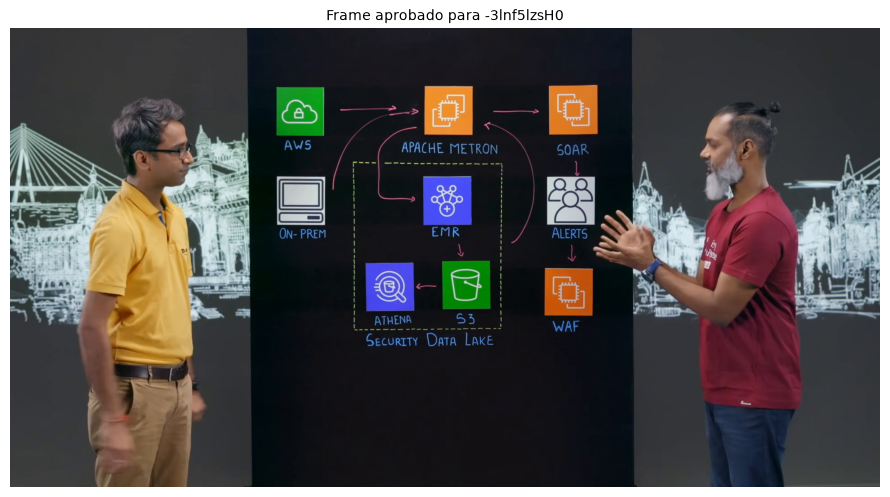

In [1]:
import csv
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

try:
    import cv2
except ImportError as e:
    raise SystemExit(
        "Falta OpenCV. La etapa de vision lo necesita:  pip install opencv-python-headless"
    ) from e

MANIFEST = Path("../data/whiteboard_manifest.csv")
EJEMPLO  = Path("../data/good_whiteboard/-3lnf5lzsH0.jpg")

MAN = list(csv.DictReader(open(MANIFEST, encoding="utf-8")))
print(f"pizarras registradas en el manifiesto: {len(MAN)}")
print(Counter(r["origen"] for r in MAN))

img = cv2.imread(str(EJEMPLO))
h, w = img.shape[:2]
print(f"\nimagen de ejemplo: {EJEMPLO.name}  ({w}x{h})")

plt.figure(figsize=(9, 5))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.title("Frame aprobado para -3lnf5lzsH0", fontsize=10)
plt.tight_layout(); plt.show()

## 2 · Qué hace cada filtro

El selector recorre el **último 80 %** de los frames (el diagrama se completa avanzado el
video) y aplica tres filtros de descarte antes de puntuar. Todo lo que sigue se demuestra
sobre la imagen de arriba.

### Filtro 1 · Detección de piel — el presentador

No descarta por sí solo: marca una bandera. Un frame **sin** piel puede ser un plano limpio
de la pizarra (bueno) o la pantalla de créditos (malo), así que la decisión se combina más
adelante con la cantidad de íconos.

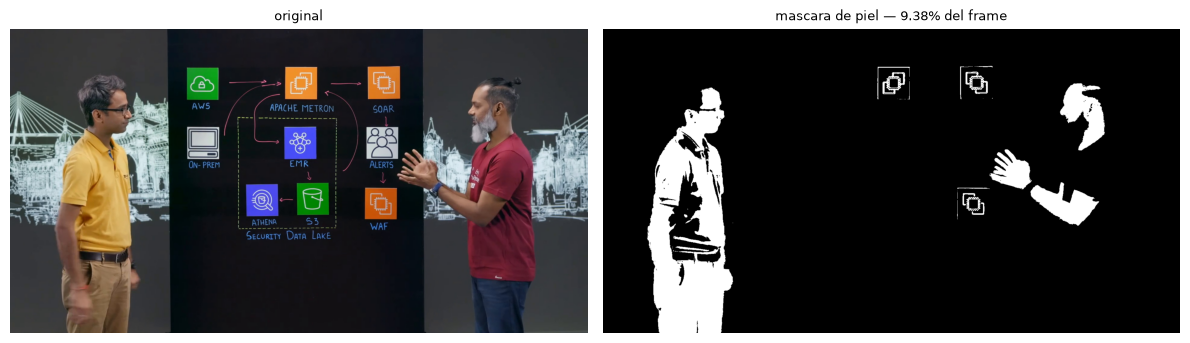

piel = 9.38%  ->  tiene_piel = True  (umbral 1.4%)


In [2]:
hsv  = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

skin_mask = cv2.inRange(hsv, (0, 30, 60), (25, 170, 255))
skin_pct  = np.sum(skin_mask > 0) / skin_mask.size
tiene_piel = skin_pct >= 0.014

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax[0].set_title("original", fontsize=9)
ax[1].imshow(skin_mask, cmap="gray")
ax[1].set_title(f"mascara de piel — {skin_pct:.2%} del frame", fontsize=9)
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

print(f"piel = {skin_pct:.2%}  ->  tiene_piel = {tiene_piel}  (umbral 1.4%)")

### Filtro 2 · Anomalía estadística — descartar la transición al outro

Los créditos finales tienen muchísimos bordes (texto denso) en la franja central. Se mide
densidad de bordes con Canny sobre la región central, previo umbral que apaga todo lo más
oscuro que 30. Si supera 0.0495, el frame se descarta.

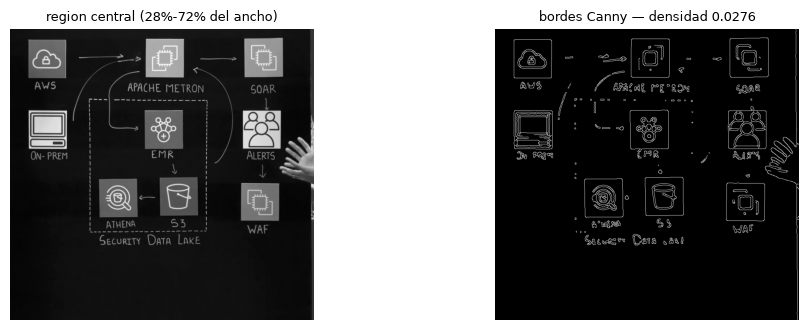

densidad 0.0276 vs umbral 0.0495  ->  pasa el filtro


In [3]:
roi_anom = gray[int(h*0.1):int(h*0.9), int(w*0.28):int(w*0.72)]
_, roi_limpio = cv2.threshold(roi_anom, 30, 255, cv2.THRESH_TOZERO)
edges_anom = cv2.Canny(cv2.medianBlur(roi_limpio, 7), 80, 200)
dens_anom  = np.sum(edges_anom > 0) / edges_anom.size

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].imshow(roi_anom, cmap="gray"); ax[0].set_title("region central (28%-72% del ancho)", fontsize=9)
ax[1].imshow(edges_anom, cmap="gray")
ax[1].set_title(f"bordes Canny — densidad {dens_anom:.4f}", fontsize=9)
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

print(f"densidad {dens_anom:.4f} vs umbral 0.0495  ->  "
      f"{'DESCARTADO' if dens_anom > 0.0495 else 'pasa el filtro'}")

### Filtro 3 · Validación de íconos AWS, con contraste de anillo

El corazón del selector. Los íconos de servicios AWS son cuadrados saturados. Se buscan
regiones saturadas, se filtran por geometría (casi cuadradas, de tamaño plausible) y
—**el paso que evita los falsos positivos**— se exige **contraste local**: se compara el
brillo del ícono contra el de un anillo de 20 px a su alrededor. Un reflejo o una mancha de
color no tiene ese salto de contraste; un ícono impreso sí.

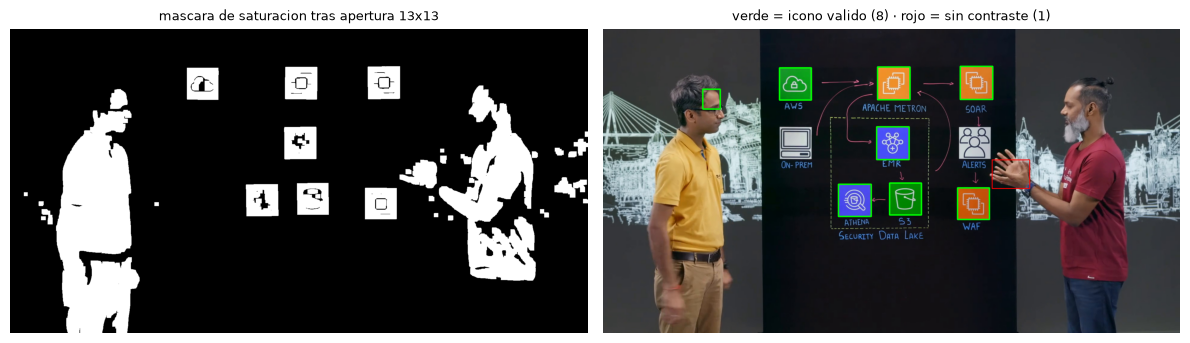

iconos validos: 8   descartados por contraste: 1
  deltas rechazados: ['7.2'] (umbral 40.0)


In [4]:
MIN_AREA, DELTA_MIN = 2000, 40.0

sat_raw  = ((hsv[:, :, 1] > 40) & (hsv[:, :, 2] > 80)).astype(np.uint8)
sat_mask = cv2.morphologyEx(sat_raw, cv2.MORPH_OPEN, np.ones((13, 13), np.uint8))
contours, _ = cv2.findContours(sat_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

validos, rechazados = [], []
for cnt in contours:
    x, y, cw, ch = cv2.boundingRect(cnt)
    area = cv2.contourArea(cnt)
    geom_ok = (0.05*min(h, w) < cw < 0.15*min(h, w)) and (0.70 < cw/ch < 1.35) and area >= MIN_AREA
    if not geom_ok:
        continue
    m = 20
    xo, yo = max(0, x-m), max(0, y-m)
    wo, ho = min(w-xo, cw+2*m), min(h-yo, ch+2*m)
    anillo = np.zeros((h, w), np.uint8)
    cv2.rectangle(anillo, (xo, yo), (xo+wo, yo+ho), 255, -1)
    cv2.rectangle(anillo, (x, y), (x+cw, y+ch), 0, -1)
    delta = abs(np.mean(gray[y:y+ch, x:x+cw]) - cv2.mean(gray, mask=anillo)[0])
    (validos if delta >= DELTA_MIN else rechazados).append((x, y, cw, ch, delta))

vis = img.copy()
for x, y, cw, ch, d in validos:     cv2.rectangle(vis, (x, y), (x+cw, y+ch), (0, 255, 0), 3)
for x, y, cw, ch, d in rechazados:  cv2.rectangle(vis, (x, y), (x+cw, y+ch), (0, 0, 255), 2)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].imshow(sat_mask*255, cmap="gray"); ax[0].set_title("mascara de saturacion tras apertura 13x13", fontsize=9)
ax[1].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
ax[1].set_title(f"verde = icono valido ({len(validos)}) · rojo = sin contraste ({len(rechazados)})", fontsize=9)
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

print(f"iconos validos: {len(validos)}   descartados por contraste: {len(rechazados)}")
if rechazados:
    print("  deltas rechazados:", [f"{d:.1f}" for *_, d in rechazados][:6], f"(umbral {DELTA_MIN})")

### Scoring

Con los frames que sobreviven, la puntuación equilibra cuatro términos:

$$\text{score} = \underbrace{5 \cdot n_{\text{iconos}}}_{\text{contenido AWS}} + \underbrace{50 \cdot \min(d_{\text{tiza}},\, 0.015)}_{\text{densidad de trazo, con tope}} - \underbrace{700 \cdot \text{oclusión}}_{\text{presentador tapando}} + \underbrace{50 \cdot \min(\text{piel},\, 0.10)}_{\text{bono, con tope}}$$

Los dos topes son deliberados: sin ellos, una pizarra saturada de trazos o un primer plano
de una persona ganarían por acumulación. La penalización por oclusión pesa 700 porque es el
error más caro — un diagrama tapado es inservible aunque esté completo.

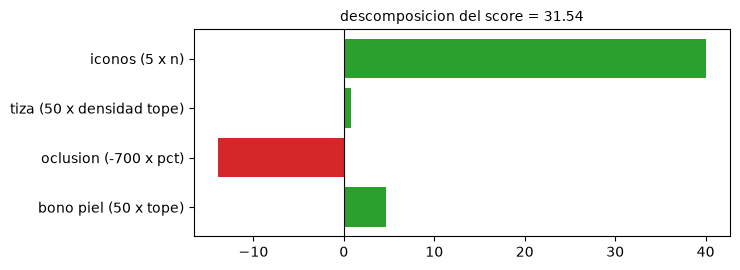

  iconos (5 x n)                +40.000
  tiza (50 x densidad tope)      +0.750
  oclusion (-700 x pct)         -13.901
  bono piel (50 x tope)          +4.689
  TOTAL                         +31.538


In [5]:
gray_masked = gray.copy()
for x, y, cw, ch, _ in validos:
    cv2.rectangle(gray_masked, (x, y), (x+cw, y+ch), 0, -1)   # los iconos no cuentan como tiza

roi   = gray_masked[int(h*0.1):int(h*0.9), int(w*0.28):int(w*0.72)]
edges = cv2.Canny(cv2.GaussianBlur(roi, (3, 3), 0), 30, 100)
dens  = np.sum(edges > 0) / edges.size
capped = min(dens, 0.015)

roi_skin  = skin_mask[int(h*0.15):int(h*0.95), int(w*0.28):int(w*0.72)]
occlusion = np.sum(roi_skin > 0) / roi_skin.size

terminos = {
    "iconos (5 x n)":            5 * len(validos),
    "tiza (50 x densidad tope)": 50 * capped,
    "oclusion (-700 x pct)":    -700 * occlusion,
    "bono piel (50 x tope)":     50 * min(skin_pct, 0.10),
}
score = sum(terminos.values())

fig, ax = plt.subplots(figsize=(7.5, 2.8))
colores = ["#2ca02c" if v >= 0 else "#d62728" for v in terminos.values()]
ax.barh(list(terminos)[::-1], list(terminos.values())[::-1], color=colores[::-1])
ax.axvline(0, c="black", lw=.8)
ax.set_title(f"descomposicion del score = {score:.2f}", fontsize=10)
plt.tight_layout(); plt.show()

for k, v in terminos.items():
    print(f"  {k:<28} {v:+8.3f}")
print(f"  {'TOTAL':<28} {score:+8.3f}")

## 3 · El manifiesto: qué imagen se usó, exactamente

Las imágenes **no se publican** (§5). Sin un registro, quien reproduzca el trabajo
re-extraería frames y obtendría *otro*, sin forma de saber cuál se usó.

`data/whiteboard_manifest.csv` cierra ese hueco: para cada video guarda el **SHA-256** de
la imagen usada y, cuando esa imagen es un frame extraído sin modificar, **cuál es**.

,video_id,sha256,bytes,origen,frame_archivo,frame_numero,frames_extraidos
0,-3lnf5lzsH0,4a068bb5c768ae47b547cbd5fcfc3db184437a77f53d99...,309961,frame_extraido,-3lnf5lzsH0_frame_13230.jpg,13230,174
1,-S-R7MWRpaI,6e65fc1a7096c3c25417abd562548abc6b059a3136b54b...,387453,frame_extraido,-S-R7MWRpaI_frame_04795.jpg,04795,76
2,-ahWdCysMYw,2b4c310a27310d2fedfc67c3a09ef7e636e8e8697cefc4...,348080,frame_extraido,-ahWdCysMYw_frame_04769.jpg,04769,51
3,-kA0ahrhX3I,1c345659c3aa6d8e4f6e86440ddc10a1ddf26ff967c99f...,395346,frame_extraido,-kA0ahrhX3I_frame_06131.jpg,06131,83
4,-wLEkq21cvA,8385eabdc98e92f32a4f20d5f6a3aab4c83750c062f9c8...,342254,frame_extraido,-wLEkq21cvA_frame_07183.jpg,07183,87
5,-yCol_7qH2U,8a77e6f228de10ac8e572f2a7e7037ff3f14e9c269458d...,239330,frame_extraido,-yCol_7qH2U_frame_07566.jpg,07566,104



origen de las 446 imagenes del estudio:
  frame_extraido      380  (85.2 %)
  reemplazo_manual     66  (14.8 %)


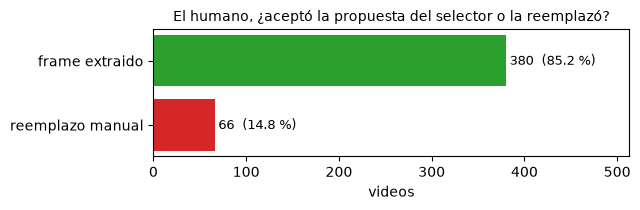

In [6]:
import pandas as pd
M = pd.DataFrame(MAN)
display(M.head(6))

origen = M.origen.value_counts()
print("\norigen de las 446 imagenes del estudio:")
for k, v in origen.items():
    print(f"  {k:<18} {v:>4}  ({100*v/len(M):.1f} %)")

fig, ax = plt.subplots(figsize=(6.5, 2.2))
ax.barh(["reemplazo manual", "frame extraido"],
        [origen.get("reemplazo_manual", 0), origen.get("frame_extraido", 0)],
        color=["#d62728", "#2ca02c"])
for i, v in enumerate([origen.get("reemplazo_manual", 0), origen.get("frame_extraido", 0)]):
    ax.text(v + 4, i, f"{v}  ({100*v/len(M):.1f} %)", va="center", fontsize=9)
ax.set_xlim(0, len(M)*1.15); ax.set_xlabel("videos")
ax.set_title("El humano, ¿aceptó la propuesta del selector o la reemplazó?", fontsize=10)
plt.tight_layout(); plt.show()

**Lectura.** En el **85 %** de los videos la imagen aprobada es, byte a byte, un frame
extraído sin tocar. En el **15 %** restante el humano eligió otra toma: son fallos del
selector identificados por curación.

Esa es la métrica honesta de esta etapa: **tasa de reemplazo manual ≈ 15 %**. Se lee como
*"en ~6 de cada 7 videos el humano aceptó la propuesta sin cambiarla"*.

### Lo que NO se puede afirmar

No hay un "frame óptimo" anotado de forma independiente. La única etiqueta disponible es la
imagen que un humano aprobó, **mirando la propuesta del propio selector**. Reportar eso
como *"precisión del selector"* sería circular: mide acuerdo con quien ya vio la respuesta.

## 4 · Hallazgo: el selector de hoy no es el que produjo el estudio

Al re-correr `frame_selector.py` sobre videos ya curados, coincide con el frame aprobado
en una fracción baja de los casos. La causa no es un error: es **deriva de versión**.

| | fecha |
|---|---|
| curación de las pizarras | 2026-06-28 → 2026-07-06 |
| últimas modificaciones de `frame_selector.py` | 2026-07-15, 07-24, **07-27** |

El historial de git lo confirma: *"tuning min_area_icono and start_idx"*, *"full video scan
and morph opening"*, *"use user's latest whiteboard selection algorithm"*, *"integrate
adaptive whiteboard detector"*. El algoritmo se siguió afinando **después** de que buena
parte de las imágenes ya estuviera curada.

**Tres consecuencias:**

1. **Re-correr el pipeline no reproduce el estudio.** Da otras imágenes. Hay que decirlo en
   amenazas a la validez.
2. **El manifiesto no es un lujo, es el único registro.** Sin él la entrada visual del
   trabajo sería irrecuperable.
3. Cualquier "precisión del selector" medida con el código actual mide **otro algoritmo**
   que el que generó los resultados. Si se reporta, hay que decir cuál.

> **Nota de seguridad.** `select_best_frame` escribe efectos secundarios: sobrescribe
> `<video>_pizarra/best_whiteboard.jpg` y vuelve a sembrar `bad_whiteboard/`, que es la
> bandeja de revisión manual. Por eso se le agregó el parámetro `write_outputs=False`, y
> `measure_frame_selector.py` lo usa: **re-medir no debe poder destruir el registro**.

## 5 · Copyright y reproducibilidad

Las imágenes son capturas de los videos de AWS *This is My Architecture*. Amazon retiene
los derechos, y este proyecto ya decidió **no redistribuir Cloudscape** por no declarar
licencia. Publicar 446 frames sería el criterio opuesto para un caso equivalente.

**Qué se publica y qué no:**

| | |
|---|---|
| ❌ las 446 imágenes | obra de terceros, porción sustancial |
| ✅ `data/whiteboard_manifest.csv` | SHA-256 + frame de origen de cada una |
| ✅ `whiteboard_sha256` en cada `run.json` | verificación cruzada por corrida |
| ✅ 1 imagen de ejemplo | uso ilustrativo mínimo, para este notebook |
| ✅ los scripts | regeneran todo desde el video |

**La verificación es más fuerte que publicar los JPG:** quien reproduzca extrae los frames,
toma el que indica el manifiesto y comprueba el hash. Si coincide, tiene *byte a byte* la
misma entrada. Si no coincide, lo sabe — en vez de creer que sí.

In [7]:
# Comprobacion cruzada: los hashes del manifiesto contra los grabados en cada corrida.
import glob
man = {r["video_id"]: r["sha256"] for r in MAN}
ok = distintos = 0
for rj in glob.glob("../reports/ablation/*_p30*/run.json"):
    d = json.loads(Path(rj).read_text(encoding="utf-8"))
    for r in d.get("results", []):
        hsh = r.get("whiteboard_sha256")
        if not hsh:
            continue
        if man.get(r["video_id"]) == hsh:
            ok += 1
        else:
            distintos += 1

print(f"comprobaciones manifiesto vs run.json : {ok + distintos}")
print(f"  coinciden : {ok}")
print(f"  distintos : {distintos}")
assert distintos == 0, "un run.json referencia una imagen que no es la del manifiesto"
print("\nOK · el manifiesto identifica exactamente las imagenes con las que se llamo a la API.")

comprobaciones manifiesto vs run.json : 600
  coinciden : 600
  distintos : 0

OK · el manifiesto identifica exactamente las imagenes con las que se llamo a la API.


## Para el paper

1. **La selección de pizarra es humana en el bucle, no automática.** El selector propone;
   una persona aprueba. Reportarlo como etapa automática sería incorrecto.
2. **Tasa de reemplazo manual ≈ 15 %**, medida por hash contra los frames extraídos. Es la
   métrica defendible; *"precisión del selector"* no lo es, porque la etiqueta no es
   independiente.
3. **El código actual del selector no reproduce las entradas del estudio** (deriva de
   versión julio 2026). Va en amenazas a la validez.
4. **Las imágenes no se redistribuyen**; la reproducibilidad se garantiza por manifiesto de
   hashes, coherente con la decisión ya tomada sobre Cloudscape.
5. El hallazgo de que **la resolución no es la causa raíz** de los fallos del selector
   (3 videos aprobados a 640×360 donde otros ~12 fallaron a la misma resolución) queda como
   hipótesis abierta: los umbrales HSV podrían estar calibrados a un estilo de pizarra.